# Лабораторная работа №3
## *Улучшение Baseline*
по курсу Анализ Акустических событий  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Шуранов Евгений Виитальевич
**выполнили:** Иванова Мария Кирилловна
**группа:** М4121

# Baseline
# Общая инициализация


#Путь к каталогу, в котором лежит датасет
датасет представлен файлом train.csv и папкой train

In [1]:
import os
import os.path as path
from google.colab import files

In [2]:
# Установите gdown
!pip install gdown

# Скачайте файлы по ID
!gdown 1OXZ-7SKtOKZJh6ta1jOocd2ZPLWHRCTZ  # train.zip
!gdown 1wI3rNJ4ii1wkvZ0l5sobKBYJsXPS-hX6  # train.csv

# Проверьте, что скачалось
!ls -lh

# Распакуйте архив
!unzip -q audio_train.zip -d /content/

# Проверьте структуру
!ls /content/audio_train/

Downloading...
From (original): https://drive.google.com/uc?id=1OXZ-7SKtOKZJh6ta1jOocd2ZPLWHRCTZ
From (redirected): https://drive.google.com/uc?id=1OXZ-7SKtOKZJh6ta1jOocd2ZPLWHRCTZ&confirm=t&uuid=6eb8304c-7573-4f16-8d81-bcfd94a4f74c
To: /content/audio_train.zip
100% 4.74G/4.74G [04:30<00:00, 17.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wI3rNJ4ii1wkvZ0l5sobKBYJsXPS-hX6
To: /content/train.csv
100% 197k/197k [00:00<00:00, 107MB/s]
total 4.5G
-rw-r--r-- 1 root root 4.5G Feb 25  2020 audio_train.zip
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data
-rw-r--r-- 1 root root 193K Feb 25  2020 train.csv
ls: cannot access '/content/audio_train/': No such file or directory


In [3]:
!unzip -q audio_train.zip -d /content/

replace /content/train/8bcbcc394ba64fe85ed4.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
train_folder = "/content/train"
train_csv = "/content/train.csv"

print("Папка существует:", os.path.exists(train_folder))
print("CSV существует:", os.path.exists(train_csv))
print("Количество аудиофайлов:", len(os.listdir(train_folder)) if os.path.exists(train_folder) else 0)

Папка существует: True
CSV существует: True
Количество аудиофайлов: 5683


In [5]:
# path
train_folder = "/content/train"
train_csv = "/content/train.csv"
train_pickle = "/content/train.pickle"
labels_pickle = "/content/labels.pickle"

# Изучение аудиофайлов датасета

In [112]:
import os
import random

import librosa
import librosa.feature as F

import numpy as np

import matplotlib.pyplot as plt

from IPython.display import Audio

In [113]:
# random filename from dir
files = os.listdir(train_folder)
filename = random.choice(files)
filename

'ed12e39d5edd7f3911ad.wav'

Спектрограмма

In [114]:
# spectrogram parameters
sample_rate = 11025

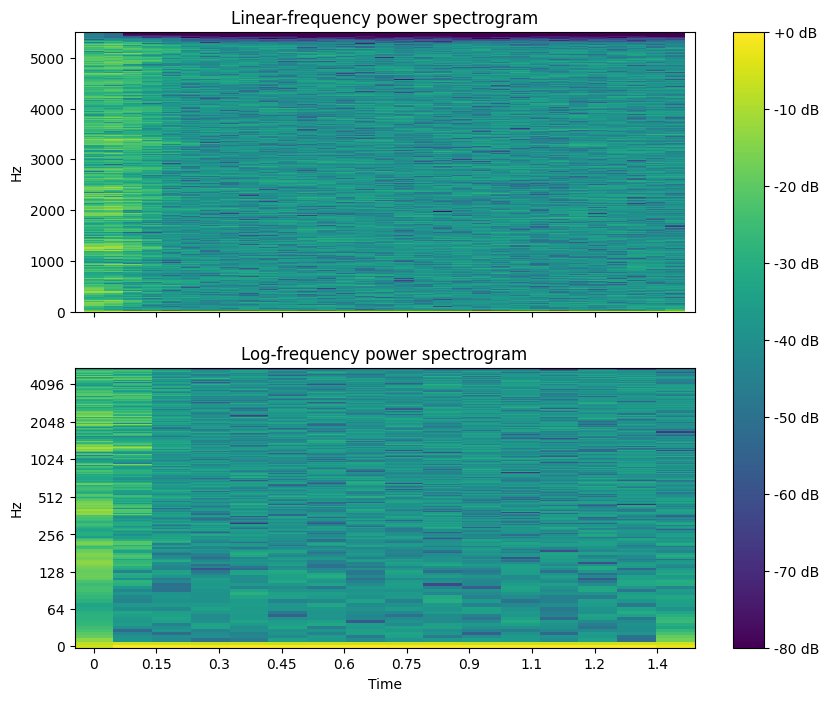

In [115]:
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=sample_rate)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

# draw linear-frequency spectrogram
hop_length = 512
wav_data_db = librosa.amplitude_to_db(
    np.abs(librosa.stft(wav_data, hop_length=hop_length)),
    ref=np.max
)
img1 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_top,
    x_axis='time',
    y_axis='linear',
    cmap=cmap,
)
ax_top.set(title='Linear-frequency power spectrogram')
ax_top.label_outer()

# draw log-frequency spectrogram
hop_length = 1024
wav_data_db = librosa.amplitude_to_db(
    np.abs(librosa.stft(wav_data, hop_length=hop_length)),
    ref=np.max
)
img2 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_bottom,
    x_axis='time',
    y_axis='log',
    cmap=cmap,
)
ax_bottom.set(title='Log-frequency power spectrogram')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

Mel-спектрограмма

In [116]:
# melspectrogram parameters
sample_rate = 11025
n_fft = 1024
overlap = 4
hop_length = n_fft // overlap
n_mels = 64

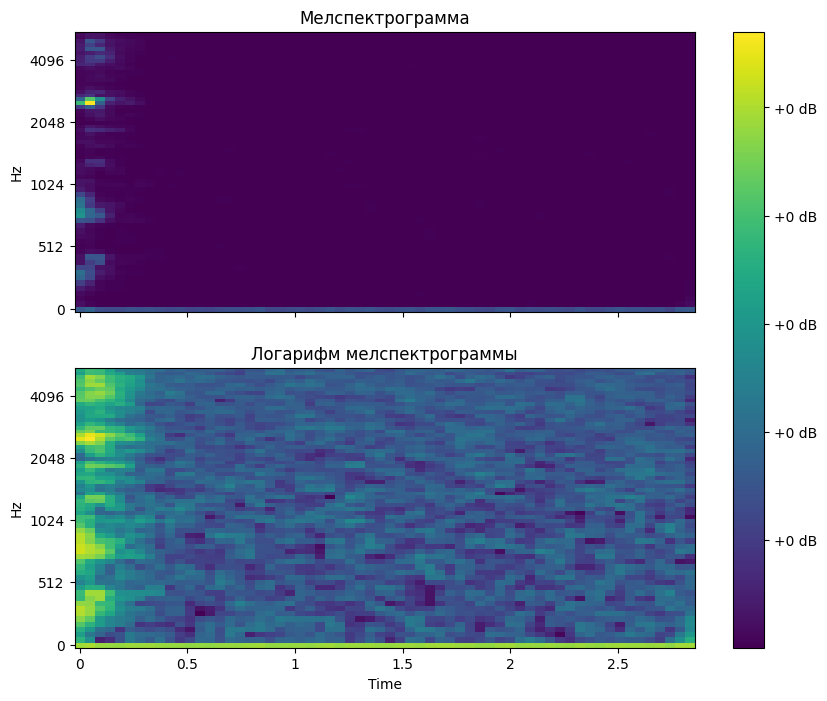

In [117]:
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=sample_rate)

mel_spec = F.melspectrogram(
    y=wav_data,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    fmax=sample_rate // 2
)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

img1 = librosa.display.specshow(
    mel_spec,
    sr=sr,
    fmax=sr // 2,
    ax=ax_top,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_top.set(title='Мелспектрограмма')
ax_top.label_outer()

D = librosa.power_to_db(mel_spec, ref=np.max)
img2 = librosa.display.specshow(
    D,
    sr=sr,
    fmax=sr // 2,
    ax=ax_bottom,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_bottom.set(title='Логарифм мелспектрограммы')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

# Извлечение признаков

In [118]:
import os
import pickle
from enum import Enum
from typing import NoReturn, Optional

from tqdm import tqdm

import pandas as pd
import numpy as np

import librosa
import librosa.feature as F


class SetType(Enum):
    """Set type"""
    TRAIN = 1
    TEST  = 2
    DEV   = 3


def extract_log_mel_feats(set_type:SetType, path_to_csv:str, path_to_files:str,
                          out_path:str, labels_pickle:str, sr:Optional[int], n_fft:int,
                          hop_length:int, n_mels:int):
    """
    Extract features from given files and store them in binary format.

    :param set_type: set tyle
    :param path_to_csv: path to loaded csv
    :param path_to_files: path to loaded data
    :param out_path: path to store extracted features
    :param labels_pickle: path to store labels dictionary
    :param sr: input files sample rate
    :param n_fft: size of fft window
    :param hop_length: hop size
    :param n_mels: number of mel band

    :return:
    """
    if set_type not in [SetType.TRAIN, SetType.TEST]:
        raise Exception(f'Such set type not supported: {set_type}')

    feats = []

    if set_type == SetType.TRAIN:
        meta = pd.read_csv(path_to_csv, skiprows=1, names=['fname', 'label'])

        file_names = list(meta['fname'])
        n_files = len(file_names)
        labels = list(meta['label'])

        uniq_labels = np.sort(np.unique(labels))
        label_to_id = {label: i for i, label in enumerate(uniq_labels)}

        print('Total files:', n_files)

        for i, (file_name, label) in tqdm(enumerate(zip(file_names, labels))):
            wav_data, sr = librosa.load(os.path.join(path_to_files, file_name), sr=sr)
            mel_spec = F.melspectrogram(
                y=wav_data,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2
            )
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            feats.append({
                'fname': file_name,
                'feature': log_mel_spec,
                'label_id': label_to_id[label]
            })

        pickle.dump(feats, open(out_path, 'wb'))
        pickle.dump(label_to_id, open(labels_pickle, 'wb'))
        return label_to_id
    else:
        for i, file_name in tqdm(enumerate(os.listdir(path_to_files))):
            wav_data, sr = librosa.load(os.path.join(path_to_files, file_name), sr=sr)
            if len(wav_data) == 0:
                wav_data = np.zeros(sr)
            mel_spec = F.melspectrogram(
                y=wav_data,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2
            )
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            feats.append({
                'fname': file_name,
                'feature': log_mel_spec,
            })

        pickle.dump(feats, open(out_path, 'wb'))
        return

In [119]:
# feature extraction parameters
sample_rate = 11025
n_fft = 1024
overlap = 4
hop_length = n_fft // overlap
n_mels = 64

In [120]:
# extract features and store to `train_pickle` extracted features
label_to_id = extract_log_mel_feats(
    SetType.TRAIN,
    train_csv,
    train_folder,
    train_pickle,
    labels_pickle,
    sample_rate,
    n_fft,
    hop_length,
    n_mels
)

id_to_label = [label for label, i in label_to_id.items()]

Total files: 5683


5683it [01:38, 57.85it/s]


# Алгоритм детектирования

## Подготовительный этап

In [121]:
from typing import NoReturn
from pprint import pprint
import random

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

In [122]:
device = device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [123]:
cpu_count = os.cpu_count()

num_workers = cpu_count if device == "cpu" else 0
num_workers, cpu_count

(0, 2)

## Добиваемся максимальной воспроизводимости

In [124]:
def set_random_state(random_state:int=0) -> NoReturn:
    """Initialize random generators.

    Parameters
    ==========
    random_state : int = 0
        Determines random number generation for centroid initialization.
        Use an int to make the randomness deterministic.
    """
    torch.manual_seed(random_state)
    random.seed(random_state)
    np.random.seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        torch.cuda.manual_seed(random_state)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [125]:
random_state = 42

In [126]:
set_random_state(random_state)

In [127]:
torch.use_deterministic_algorithms(True)

In [128]:
%env CUBLAS_WORKSPACE_CONFIG=:4096:8
%env PYTHONHASHSEED=42

env: CUBLAS_WORKSPACE_CONFIG=:4096:8
env: PYTHONHASHSEED=42


## Архитектура нейронной сети

In [267]:
class DummyNetwork(nn.Module):
    def __init__(self, input_height=64, input_width=64):
        super().__init__()

        # Свёрточные слои (больше каналов, 4 слоя)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, stride=2, padding=2)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        # Pooling
        self.mp = nn.MaxPool2d(kernel_size=2, stride=1)

        # Dropout (умеренный)
        self.dropout1 = nn.Dropout(p=0.4)
        self.dropout2 = nn.Dropout(p=0.4)
        self.dropout3 = nn.Dropout(p=0.4)
        self.dropout4 = nn.Dropout(p=0.4)

        self.flat = nn.Flatten()

        # Автоматический расчёт размера для fc1
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_height, input_width)
            dummy = self._forward_conv(dummy)
            flatten_size = dummy.view(1, -1).size(1)

        self.fc1 = nn.Linear(flatten_size, 41)
        print(f"Автоматически вычисленный размер: {flatten_size}")

    def _forward_conv(self, x):
        # Слой 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout1(x)

        # Слой 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout2(x)

        # Слой 3 (новый)
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout3(x)

        # Слой 4 (новый)
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout4(x)

        return x

    def forward(self, x):
        x = self._forward_conv(x)
        x = self.flat(x)
        x = self.fc1(x)

        return x



In [268]:
set_random_state(random_state) # try to run this cell several times
                               # then comment this line and run it several times again
                               # * pay attention at tensors values

# random 4D tensor
random_input = torch.randn(1, 1, 64, 64, requires_grad=True, device=device)

print(f"Исходный тензор {list(random_input.shape)}:")
pprint(random_input)

# create neural network instance
network = DummyNetwork().to(device)

# pass data throught the neural network
output = network(random_input)

print(f"\nТензор на выходе нейронной сети {list(output.shape)}:")
pprint(output)

Исходный тензор [1, 1, 64, 64]:
tensor([[[[ 0.1940,  2.1614, -0.1721,  ..., -0.8146,  0.2502, -0.4273],
          [ 1.1044, -1.1028,  0.5543,  ..., -1.2072, -0.2438, -0.6784],
          [ 0.1973,  0.9782, -0.0287,  ..., -0.1266, -0.4321, -1.3943],
          ...,
          [-1.1998,  0.5818, -0.7198,  ..., -0.6079, -1.8145,  0.2807],
          [-0.0970,  0.9319, -0.4393,  ..., -0.1155, -0.0528,  1.1175],
          [ 3.0098,  1.3304, -1.1632,  ...,  0.1124,  0.2769, -1.2535]]]],
       device='cuda:0', requires_grad=True)
Автоматически вычисленный размер: 100352

Тензор на выходе нейронной сети [1, 41]:
tensor([[ 0.4991,  0.5646, -1.0747,  1.1246, -0.7631, -1.6474,  0.5053, -0.2643,
          0.8328,  1.6396, -0.6811,  1.4579,  0.3741,  0.6137,  0.6617,  0.3548,
          0.2683,  0.4626, -1.0009, -1.5594, -0.1702, -1.5274, -0.8526,  1.4324,
          0.1208,  0.2636, -0.3801,  0.5719, -1.7579, -0.5124,  0.9531, -0.8797,
         -0.1536, -1.0611, -0.1870, -0.5151,  0.3605, -1.4051, -2.0

## Шаг оптимизации

In [269]:
import torch.optim as optim

In [270]:
set_random_state(random_state)


# choose loss function
criterion = nn.CrossEntropyLoss()

# choose and tune optimizer
#optimizer = optim.SGD(network.parameters(), lr=0.001)
optimizer = optim.AdamW(network.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
optimizer.zero_grad()

random_input = torch.randn(3, 1, 64, 64, requires_grad=True, device=device)
print(f"Тензор на входе сети {list(random_input.shape)}:")
pprint(random_input)

output = network(random_input)
print(f"\nТензор на выходе сети {list(output.shape)}:")
pprint(output)

target = torch.randint(5, (3,), dtype=torch.long, device=device)
print(f"\nТензор с целевыми значениями {list(target.shape)}:")
pprint(target)

loss = criterion(output, target)
print("\nЗначение функции потерь:", loss.item())

# backpropagation
loss.backward()

# next step
optimizer.step()

Тензор на входе сети [3, 1, 64, 64]:
tensor([[[[ 0.1940,  2.1614, -0.1721,  ..., -0.8146,  0.2502, -0.4273],
          [ 1.1044, -1.1028,  0.5543,  ..., -1.2072, -0.2438, -0.6784],
          [ 0.1973,  0.9782, -0.0287,  ..., -0.1266, -0.4321, -1.3943],
          ...,
          [-1.1998,  0.5818, -0.7198,  ..., -0.6079, -1.8145,  0.2807],
          [-0.0970,  0.9319, -0.4393,  ..., -0.1155, -0.0528,  1.1175],
          [ 3.0098,  1.3304, -1.1632,  ...,  0.1124,  0.2769, -1.2535]]],


        [[[ 1.1346, -0.6329, -0.9147,  ..., -1.5122, -1.1374,  0.7628],
          [ 0.9661, -0.0587, -0.2129,  ...,  1.2377,  0.5842,  1.6728],
          [ 0.7942,  0.3131, -0.3607,  ...,  0.1261, -0.1309,  2.0342],
          ...,
          [-0.3319,  0.8590,  0.7535,  ..., -1.2910, -0.3644,  0.9805],
          [-0.5130,  0.6719, -0.1551,  ..., -0.4551, -0.1417, -1.2772],
          [-0.4063,  0.0820,  0.8311,  ..., -1.0449,  1.5397, -2.0042]]],


        [[[-0.5852, -0.9346,  0.9684,  ...,  0.5966, -1.6748,

# Обучение нейронной сети

## Загрузка ранее извлеченных признаков и подготовка данных для обучения

In [271]:
import pickle

In [272]:
train_data = pickle.load(open(train_pickle, "rb"))

label_to_id = pickle.load(open(labels_pickle, "rb"))
id_to_label = [label for label, i in label_to_id.items()]

In [273]:
def prepare_shape(feature):
    tmp = feature
    N = 64 # размер во времени (можно увеличить, должно стать лучше)
    while tmp.shape[1] < N:
        # можно попробовать сделать np.pad для коротких файлов, вместо повторения до необходимой длины
        tmp = np.hstack((tmp, tmp))
    # случайный сдвиг должен улучшить результат (для этого нужно функцию перенести в EventDetectionDataset)
    tmp = tmp[np.newaxis, :, :N]
    return tmp

In [274]:
from sklearn.model_selection import StratifiedShuffleSplit

# Подготовка данных
all_features = [prepare_shape(row['feature']) for row in train_data]  # важно: apply prepare_shape!
all_labels = [row['label_id'] for row in train_data]

# Стратифицированное разделение
sss = StratifiedShuffleSplit(n_splits=1, test_size=800, random_state=42)
train_idx, val_idx = next(sss.split(all_features, all_labels))

# Формирование обучающей и валидационной выборок
x_tr = [all_features[i] for i in train_idx]
y_tr = [all_labels[i] for i in train_idx]
x_val = [all_features[i] for i in val_idx]
y_val = [all_labels[i] for i in val_idx]

# Преобразование в numpy массивы
x_tr = np.asarray(x_tr)
x_val = np.asarray(x_val)
y_tr = np.asarray(y_tr)
y_val = np.asarray(y_val)

print(f"""
Train set:
    x.shape: {x_tr.shape}
    y.shape: {y_tr.shape}

Validation set:
    x.shape: {x_val.shape}
    y.shape: {y_val.shape}
""")


Train set:
    x.shape: (4883, 1, 64, 64)
    y.shape: (4883,)

Validation set:
    x.shape: (800, 1, 64, 64)
    y.shape: (800,)



In [249]:
from torch.utils.data import Dataset

In [275]:
class EventDetectionDataset(Dataset):
    def __init__(self, x, y=None, augment=False, device="cpu"):
        self.x = x
        self.y = y
        self.augment = augment
        self.device = device

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        feature = self.x[idx].copy()

        if self.augment:
            shift = np.random.randint(-24, 25) # сдвиг ±24 кадров
            feature = np.roll(feature, shift, axis=2)
            if shift > 0:
                feature[:, :, :shift] = 0
            else:
                feature[:, :, shift:] = 0

        if self.y is not None:
            return torch.tensor(feature, device=self.device), torch.tensor(self.y[idx], device=self.device)
        return torch.tensor(feature, device=self.device)

In [276]:
train_dset = EventDetectionDataset(x_tr, y_tr, augment=True, device=device)
val_dset = EventDetectionDataset(x_val, y_val, augment=False, device=device)

In [277]:
set_random_state(random_state)

sample_x, sample_y = random.choice(val_dset)

sample_y.item(), id_to_label[sample_y]

(26, np.str_('Laughter'))

In [278]:
import librosa
import matplotlib.pyplot as plt

In [279]:
sample_rate = 11025

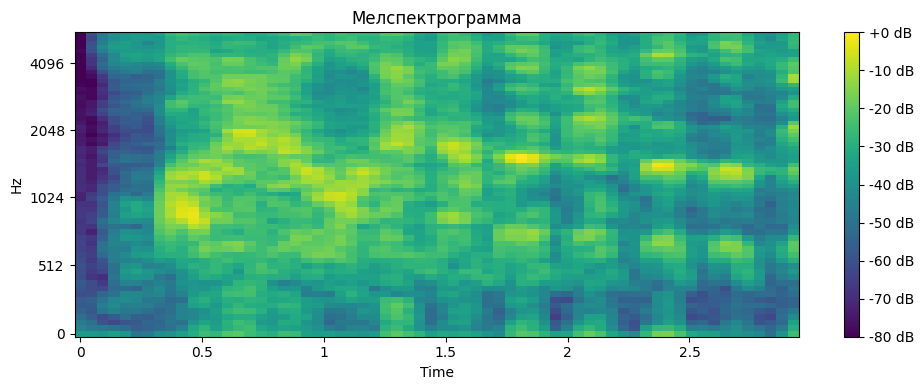

In [280]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
cmap = "viridis"

img = librosa.display.specshow(
    sample_x[0].numpy(force=True),
    sr=sample_rate,
    fmax=sample_rate // 2,
    ax=ax,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax.set(title='Мелспектрограмма')
ax.label_outer()

fig.colorbar(img, ax=ax, format="%+2.f dB")
plt.tight_layout()
plt.show()

In [281]:
from torch.utils.data import DataLoader

In [282]:
train_loader = DataLoader(train_dset, batch_size=41, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dset, batch_size=41, shuffle=False, num_workers=num_workers)

In [283]:
import time
from sklearn.metrics import accuracy_score

In [284]:
start_time = time.time()

n_epoch = 100

set_random_state(random_state)

criterion = nn.CrossEntropyLoss()
network = DummyNetwork().to(device)

optimizer = optim.AdamW(network.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

train_loss = []
val_loss = []
train_acc = []
val_acc = []

best_val_acc = 0
patience = 15
patience_counter = 0
best_epoch = 0

for e in range(n_epoch):
    print(f'epoch #{e+1}')

    # train
    loss_list = []
    outputs = []
    targets = []
    for i_batch, sample_batched in enumerate(train_loader):
        x, y = sample_batched
        optimizer.zero_grad()

        output = network(x)
        outputs.append(output.argmax(axis=1))

        target = y
        targets.append(target)

        loss = criterion(output, target.long())
        loss_list.append(loss.item())
        loss.backward()
        optimizer.step()

    y_true = torch.hstack(targets).numpy(force=True)
    y_pred = torch.hstack(outputs).numpy(force=True)
    acc = accuracy_score(y_true, y_pred)

    train_loss.append(np.mean(loss_list))
    train_acc.append(acc)

    print(f'[train] mean loss: {train_loss[-1]}')
    print(f'[train] accuracy:  {acc}')

    loss_list = []
    outputs = []
    targets = []
    with torch.no_grad():
        for i_batch, sample_batched in enumerate(val_loader):
            x, y = sample_batched

            output = network(x)
            outputs.append(output.argmax(axis=1))

            target = y
            targets.append(target)

            loss = criterion(output, target.long())
            loss_list.append(loss.item())

        y_true = torch.hstack(targets).numpy(force=True)
        y_pred = torch.hstack(outputs).numpy(force=True)
        acc = accuracy_score(y_true, y_pred)

        val_loss.append(np.mean(loss_list))
        val_acc.append(acc)

        print(f'[val] mean loss:   {val_loss[-1]}')
        print(f'[val] accuracy:    {acc}', end="\n\n")

        scheduler.step(val_loss[-1])

        if acc > best_val_acc:
            best_val_acc = acc
            patience_counter = 0
            best_epoch = e + 1
            torch.save(network.state_dict(), 'best_model.pt')
            print(f" Новая лучшая модель. Точность: {best_val_acc:.4f} на эпохе {best_epoch}")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {e+1}")
            break

network.load_state_dict(torch.load('best_model.pt'))
print(f"\nЛучшая модель: эпоха {best_epoch}, точность {best_val_acc:.4f}")

print(f"Execution time: {(time.time() - start_time):.2f} seconds")

Автоматически вычисленный размер: 100352
epoch #1
[train] mean loss: 30.724678150812785
[train] accuracy:  0.05119803399549457
[val] mean loss:   24.708177947998045
[val] accuracy:    0.075

 Новая лучшая модель. Точность: 0.0750 на эпохе 1
epoch #2
[train] mean loss: 10.437574760119121
[train] accuracy:  0.10485357362277288
[val] mean loss:   14.181329250335693
[val] accuracy:    0.1025

 Новая лучшая модель. Точность: 0.1025 на эпохе 2
epoch #3
[train] mean loss: 5.02752174337705
[train] accuracy:  0.15523243907433953
[val] mean loss:   8.491809964179993
[val] accuracy:    0.15

 Новая лучшая модель. Точность: 0.1500 на эпохе 3
epoch #4
[train] mean loss: 2.930303140481313
[train] accuracy:  0.23837804628302273
[val] mean loss:   9.91301624774933
[val] accuracy:    0.15625

 Новая лучшая модель. Точность: 0.1562 на эпохе 4
epoch #5
[train] mean loss: 2.606482713421186
[train] accuracy:  0.2983821421257424
[val] mean loss:   11.38841278553009
[val] accuracy:    0.1425

epoch #6
[train

In [65]:
window = 10
recent_val_acc = val_acc[-window:]

best_val_acc = max(val_acc)
best_val_loss = min(val_loss)
avg_recent_val_acc = np.mean(recent_val_acc)

print ("baseline")
print(f"Лучшая точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%) на эпохе {best_epoch}")
print(f"Средняя точность за последние {window} эпох: {avg_recent_val_acc:.4f}")
print(f"Лучшая валидационная потеря: {best_val_loss:.4f}")

baseline
Лучшая точность: 0.4788 (47.88%) на эпохе 30
Средняя точность за последние 10 эпох: 0.4070
Лучшая валидационная потеря: 1.9047


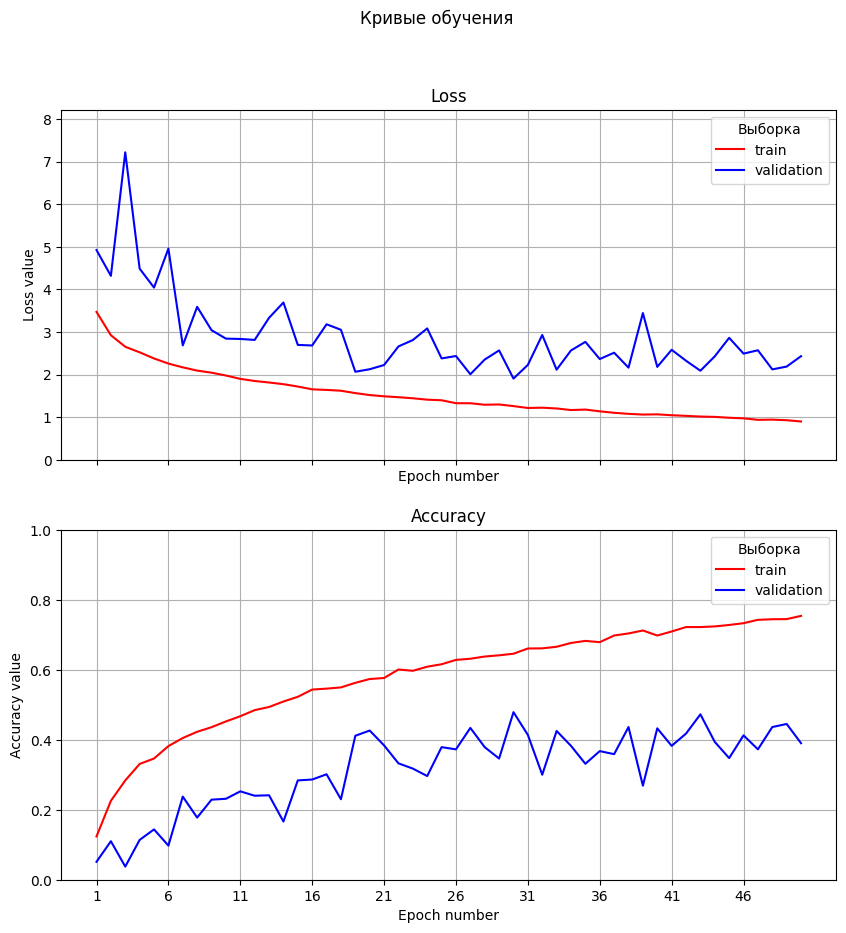

In [43]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

# Улучшения


# Stratified
Стратифицированное разделение выборки позволяет сохранить исходное распределение классов в обучающей и валидационной выборках, что способствует более сбалансированному разбиению и, следовательно, обеспечивает "честную" и объективную оценку качества модели, особенно при работе с несбалансированными данными.

In [78]:
window = 10
recent_val_acc = val_acc[-window:]

best_val_acc = max(val_acc)
best_val_loss = min(val_loss)
avg_recent_val_acc = np.mean(recent_val_acc)

print ("stratified")
print(f"Лучшая точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%) на эпохе {best_epoch}")
print(f"Средняя точность за последние {window} эпох: {avg_recent_val_acc:.4f}")
print(f"Лучшая валидационная потеря: {best_val_loss:.4f}")

stratified
Лучшая точность: 0.4775 (47.75%) на эпохе 30
Средняя точность за последние 10 эпох: 0.3899
Лучшая валидационная потеря: 2.0717


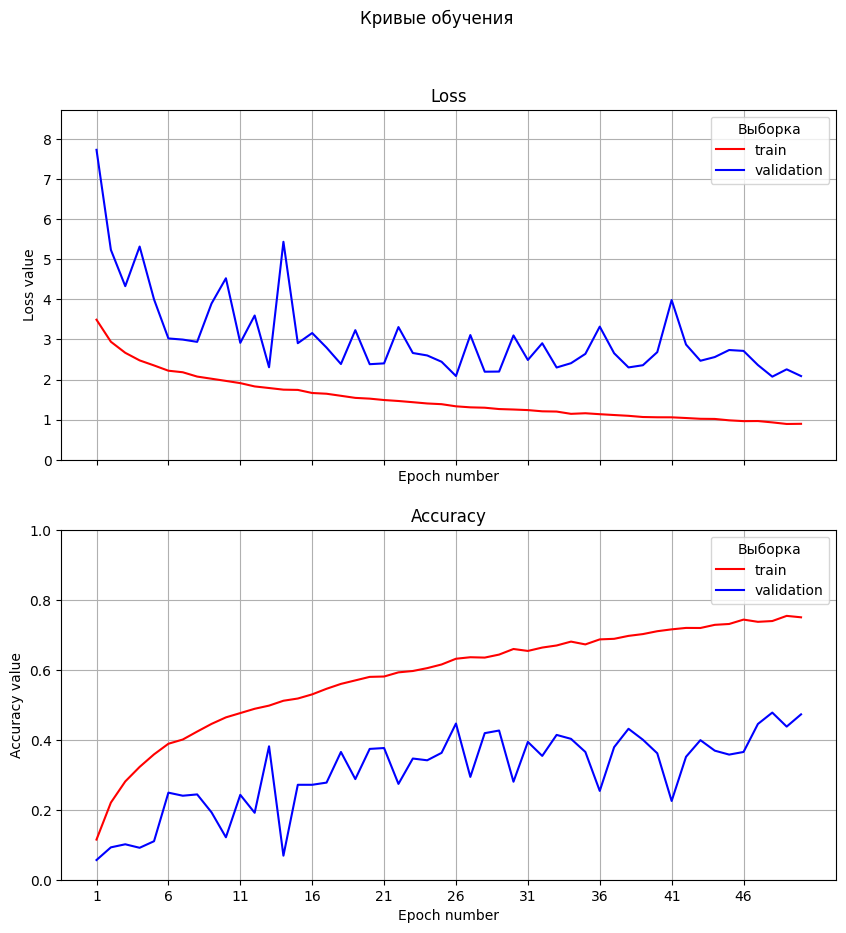

In [79]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

## Увеличение размера во времени с 64 до 128
Увеличение временного размера спектрограммы с 64 до 128 кадров позволяет модели анализировать более длинные временные контексты аудиособытия.

Это может помочь захватывать долгосрочные зависимости, снижать чувствительность к сдвигу.
Увеличение окна может позволить сохранить всю значимую информацию без обрезания.

In [153]:
window = 10
recent_val_acc = val_acc[-window:]

best_val_acc = max(val_acc)
best_val_loss = min(val_loss)
avg_recent_val_acc = np.mean(recent_val_acc)

print ("baseline")
print(f"Лучшая точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%) на эпохе {best_epoch}")
print(f"Средняя точность за последние {window} эпох: {avg_recent_val_acc:.4f}")
print(f"Лучшая валидационная потеря: {best_val_loss:.4f}")

baseline
Лучшая точность: 0.4525 (45.25%) на эпохе 30
Средняя точность за последние 10 эпох: 0.3041
Лучшая валидационная потеря: 2.3725


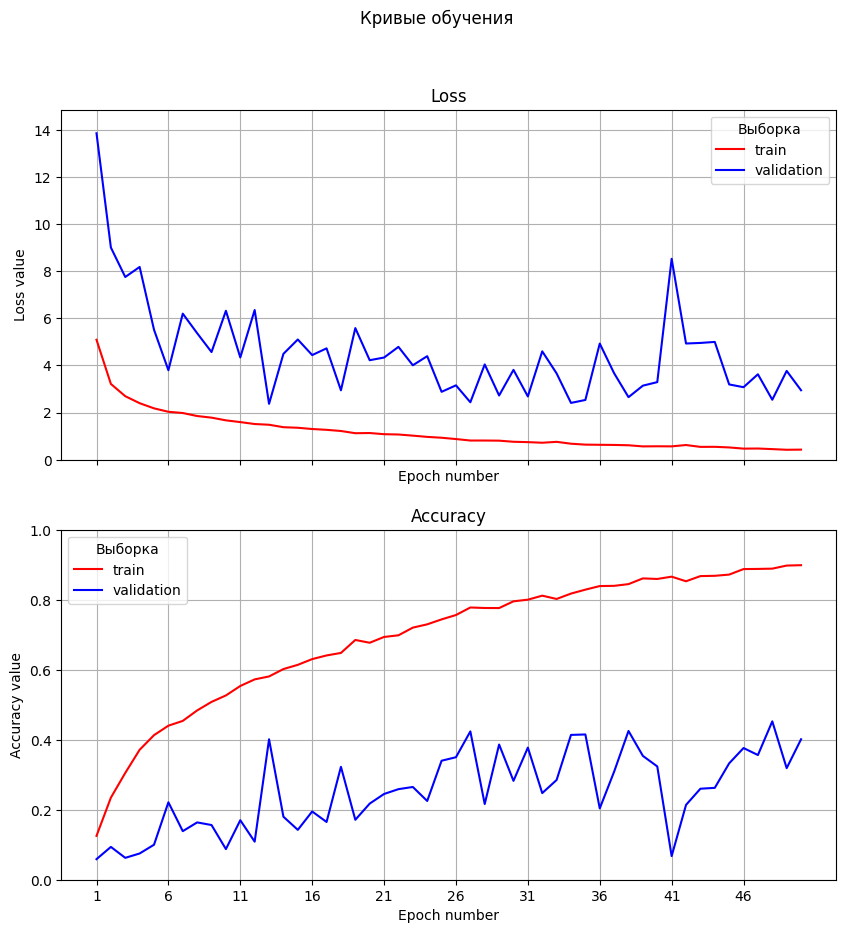

In [154]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

## Adam + dropout = 0.5
Adam ускоряет сходимость и позволяет эффективнее настраивать веса.

Dropout: случайное "выключение" нейронов во время обучения снижает переобучение, которое пока велико.

In [177]:
window = 10
recent_val_acc = val_acc[-window:]

best_val_acc = max(val_acc)
best_val_loss = min(val_loss)
avg_recent_val_acc = np.mean(recent_val_acc)

print ("baseline")
print(f"Лучшая точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%) на эпохе {best_epoch}")
print(f"Средняя точность за последние {window} эпох: {avg_recent_val_acc:.4f}")
print(f"Лучшая валидационная потеря: {best_val_loss:.4f}")

baseline
Лучшая точность: 0.4512 (45.12%) на эпохе 30
Средняя точность за последние 10 эпох: 0.3743
Лучшая валидационная потеря: 2.1577


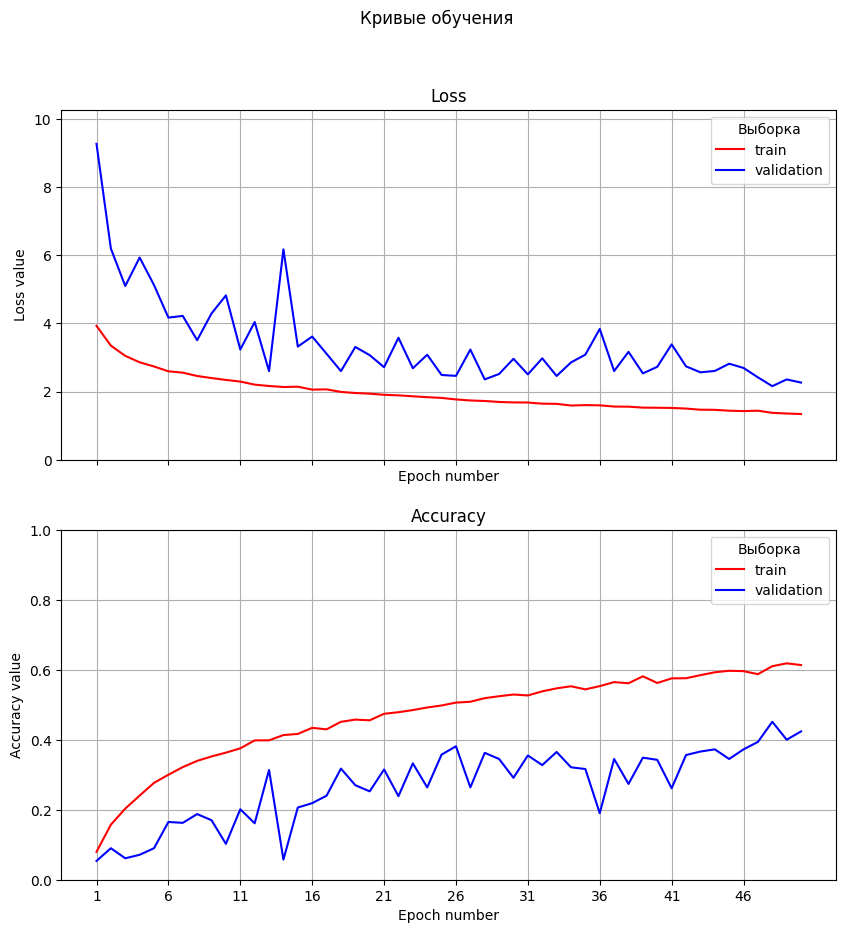

In [178]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

## AdamW + augumentation сдвиг на 16 кадров

AdamW - улучшенная версия Adam с корректной регуляризацией весов (weight decay), что снижает переобучение и стабилизирует обучение.

Аугментация со сдвигом делает модель инвариантной к временным сдвигам звукового события. Это повышает обобщающую способность и снижает риск переобучения.

In [213]:
window = 10
recent_val_acc = val_acc[-window:]

best_val_acc = max(val_acc)
best_val_loss = min(val_loss)
avg_recent_val_acc = np.mean(recent_val_acc)

print ("AdamW + aug")
print(f"Лучшая точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%) на эпохе {best_epoch}")
print(f"Средняя точность за последние {window} эпох: {avg_recent_val_acc:.4f}")
print(f"Лучшая валидационная потеря: {best_val_loss:.4f}")

AdamW + aug
Лучшая точность: 0.4575 (45.75%) на эпохе 30
Средняя точность за последние 10 эпох: 0.3686
Лучшая валидационная потеря: 2.1328


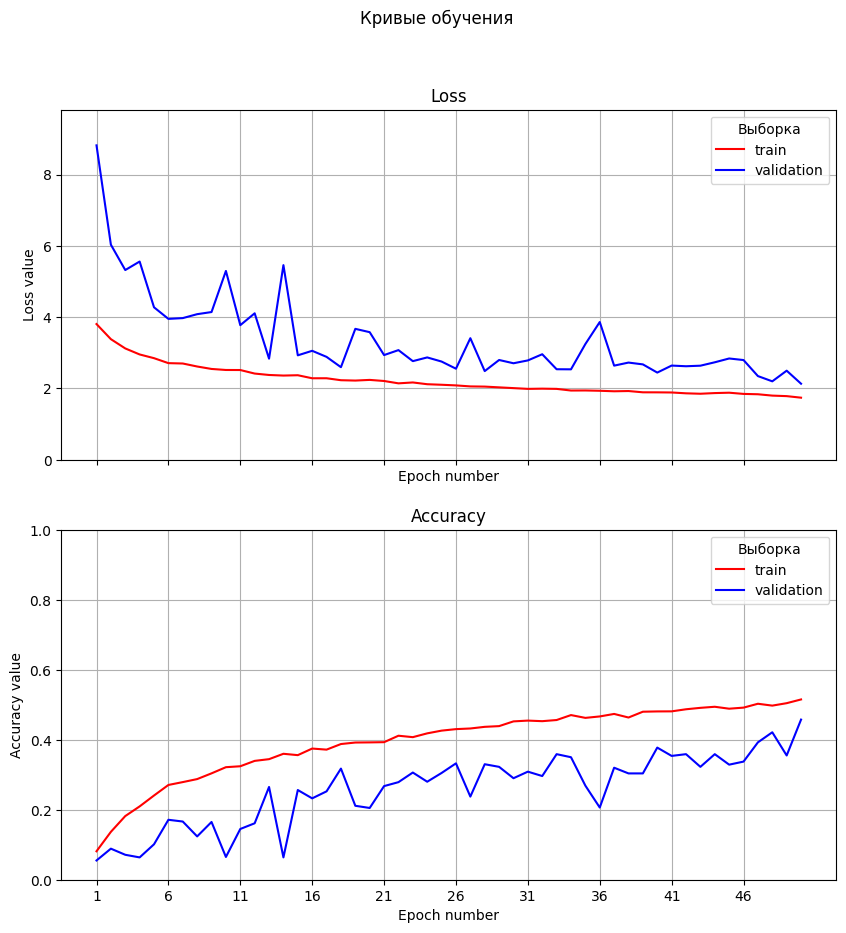

In [211]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

## AdamW + aug 24 + 100 эпох + настройка learning rate
AdamW  - корректная регуляризация весов, снижает переобучение.

Аугментация 24 — более сильный сдвиг, делает модель устойчивее к временным вариациям.

100 эпох позволяет модели доучиться до сходимости, особенно при использовании регуляризации и аугментации.

Настройка learning rate помогает точнее настроить веса на финальных этапах и избежать "перескакивания" минимума.

In [266]:
window = 10
recent_val_acc = val_acc[-window:]

best_val_acc = max(val_acc)
best_val_loss = min(val_loss)
avg_recent_val_acc = np.mean(recent_val_acc)

print ("AdamW + aug 24 + настройка learning rate")
print(f"Лучшая точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Средняя точность за последние {window} эпох: {avg_recent_val_acc:.4f}")
print(f"Лучшая валидационная потеря: {best_val_loss:.4f}")

AdamW + aug 24 + настройка learning rate
Лучшая точность: 0.4487 (44.88%)
Средняя точность за последние 10 эпох: 0.3864
Лучшая валидационная потеря: 2.1895


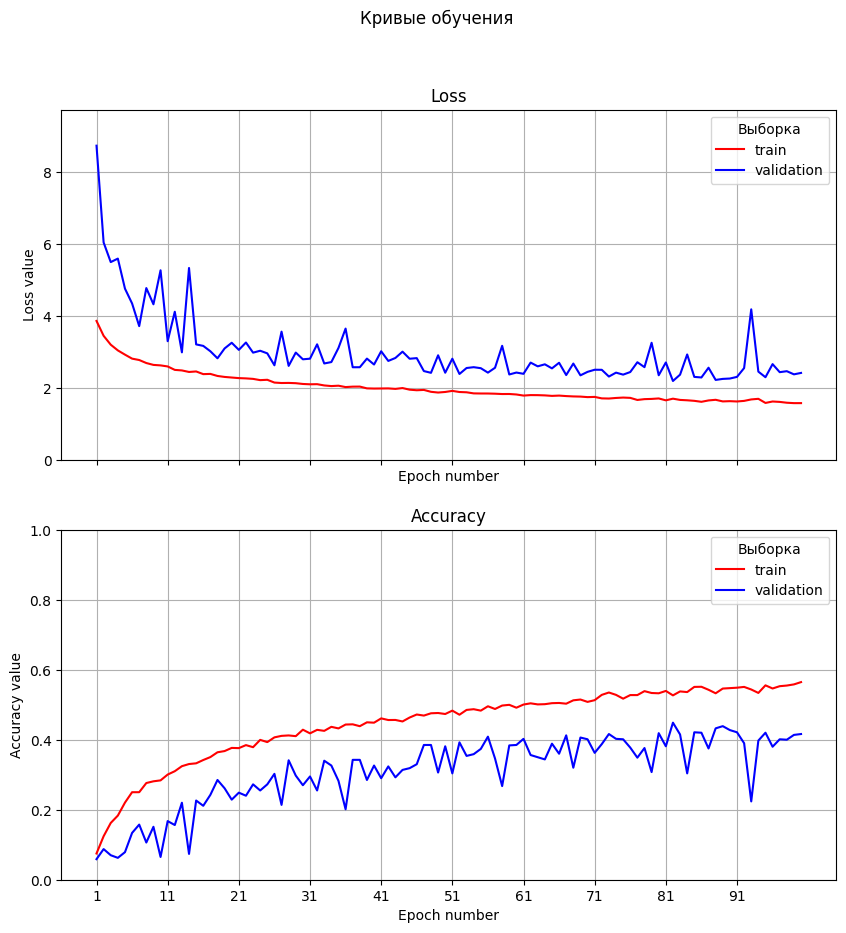

In [264]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

## Aug 24 + Stratified Split + AdamW + 100 Epochs + Early stopping + 4 Layers
Итоговая усложненная конфигурация, объединяющая все успешные улучшения
- Aug 24	Аугментация (сдвиг 24 кадра) для устойчивости к временным сдвигам, и расширения выборки
- Stratified Split для сохранения пропорций классов
- AdamW	Оптимизатор с корректной регуляризацией весов, снижает переобучение
- 100 Epochs для полной сходимости модели
- Early stopping предотвращает переобучение и экономит время
- 4 Layers

In [289]:
window = 10
recent_val_acc = val_acc[-window:]

best_val_acc = max(val_acc)
best_val_loss = min(val_loss)
avg_recent_val_acc = np.mean(recent_val_acc)

print ("Augmentation 24 + AdamW + 100 эпох + 4 слоя")
print(f"Лучшая точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Средняя точность за последние {window} эпох: {avg_recent_val_acc:.4f}")
print(f"Лучшая валидационная потеря: {best_val_loss:.4f}")

Augmentation 24 + AdamW + 100 эпох + 4 слоя
Лучшая точность: 0.4713 (47.12%)
Средняя точность за последние 10 эпох: 0.4631
Лучшая валидационная потеря: 4.0786


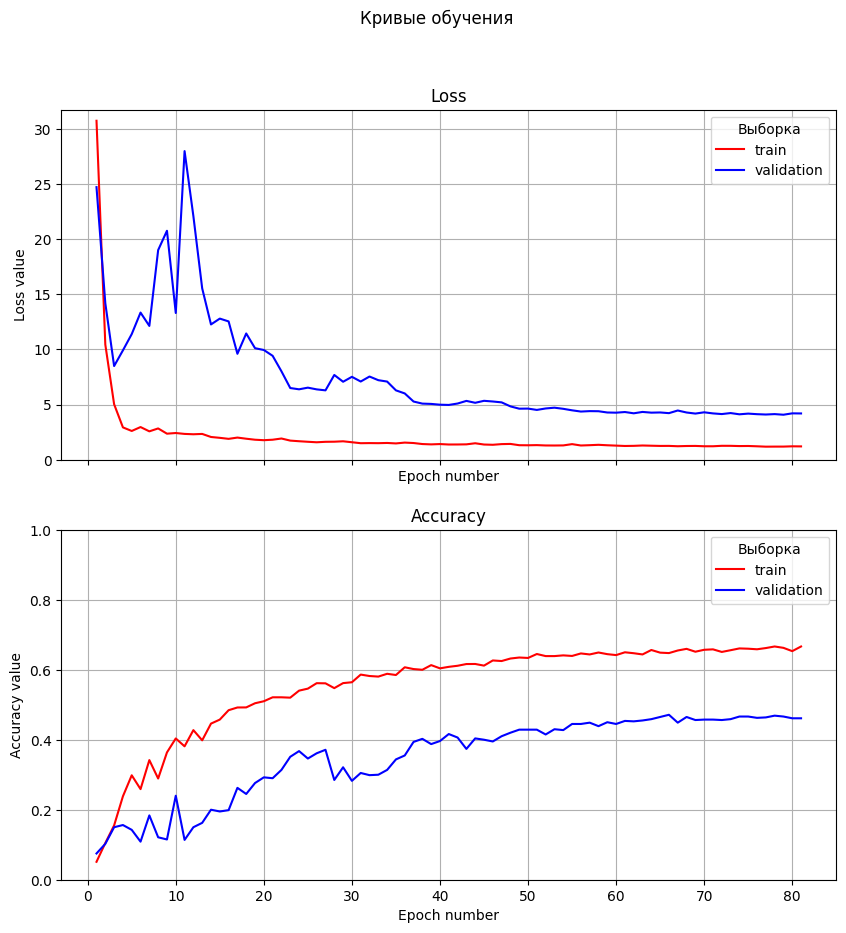

In [288]:
epochs_train = range(1, len(train_loss) + 1)
epochs_val = range(1, len(val_loss) + 1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

ax_top.plot(epochs_train, train_loss, 'r', label='train')
ax_top.plot(epochs_val, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(title="Выборка")
ax_top.grid()

ax_bottom.plot(epochs_train, train_acc, 'r', label='train')
ax_bottom.plot(epochs_val, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    ylim=[0, 1],
)
ax_bottom.legend(title="Выборка")
ax_bottom.grid()

fig.suptitle("Кривые обучения")
plt.show()

# Итоги экспериментов

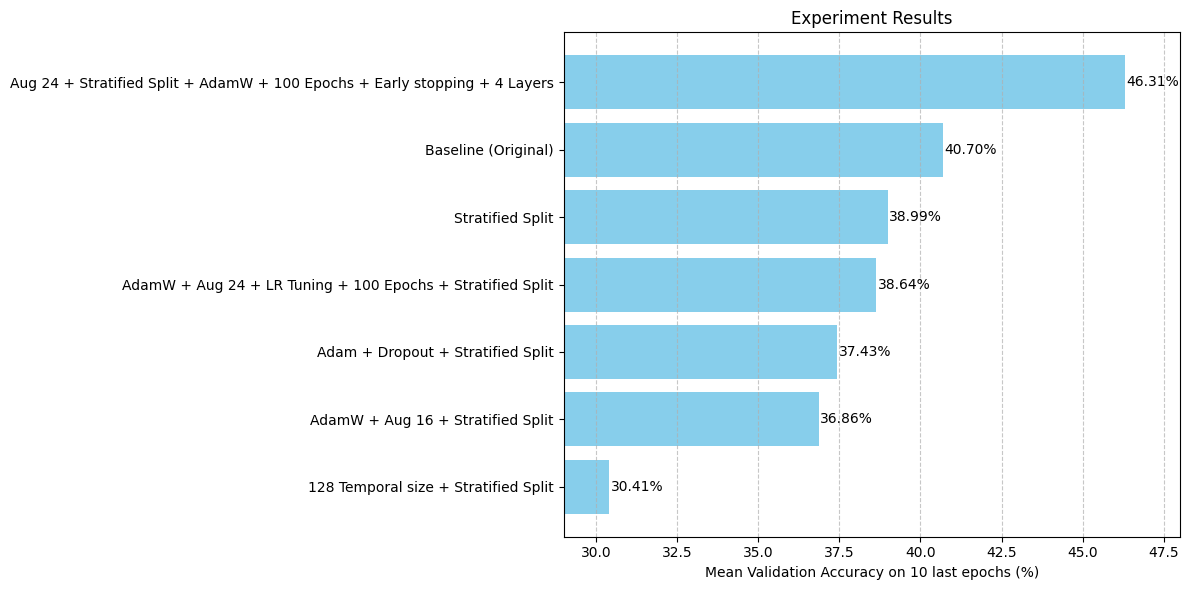

In [303]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the experiments
experiments = [
    "Baseline (Original)",
    "Stratified Split",
    "128 Temporal size + Stratified Split",
    "Adam + Dropout + Stratified Split",
    "AdamW + Aug 16 + Stratified Split",
    "AdamW + Aug 24 + LR Tuning + 100 Epochs + Stratified Split",
    "Aug 24 + Stratified Split + AdamW + 100 Epochs + Early stopping + 4 Layers"
]

best_accuracies = [
    40.7,  # Baseline (Original)
    38.99,  # Stratified Split
    30.41,  # 128 Temporal size + Stratified Split
    37.43,  # Adam + Dropout + Stratified Split
    36.86,  # AdamW + Aug 16 + Stratified Split
    38.64,  # AdamW + Aug 24 + LR Tuning + Stratified Split
    46.31   # Aug 24 + Stratified Split + AdamW + 100 Epochs + 4 Layers
]

sorted_indices = np.argsort(best_accuracies)
sorted_experiments = [experiments[i] for i in sorted_indices]
sorted_accuracies = [best_accuracies[i] for i in sorted_indices]

plt.figure(figsize=(12, 6))
bars = plt.barh(sorted_experiments, sorted_accuracies, color='skyblue')
plt.xlabel('Mean Validation Accuracy on 10 last epochs (%)')
plt.title('Experiment Results')
plt.xlim(29, 48)  # Focus on the relevant range
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar, acc in zip(bars, sorted_accuracies):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{acc:.2f}%', va='center')

plt.tight_layout()
plt.show()

# Вывод

### В ходе экспериментов были внесены и протестированы различные улучшения, среди которых наиболее эффективными оказались следующие:


1.   ### **Стратифицированное разделение (StratifiedShuffleSplit)** выборки обеспечило корректную оценку модели на всех этапах.
2.   ### **Аугментация** данных (сдвиг спектрограммы на 24 отсчеиа) повысила обобщающую способность модели.
3. ### **Усложнение архитектуры** (4 слоя), замена оптимизатора на **AdamW** и настройка **learning rate** позволили добиться значительного прироста точности.
4. ### Добавление **early stopping** и увеличение dropout способствовали снижению переобучения.

## Результат:
### Финальные графики обучения стали заметно более плавными, что свидетельствует о стабилизации процесса и снижении переобучения. Комбинация улучшений дала наилучший результат — 46.31% (усреднение accuracy по последним 10 эпохам).

